In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [31]:
df = pd.read_csv("fake_job_postings.csv")

In [32]:
df.head()

df.info()

df.describe()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='object')

In [33]:
df.isnull().sum()

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


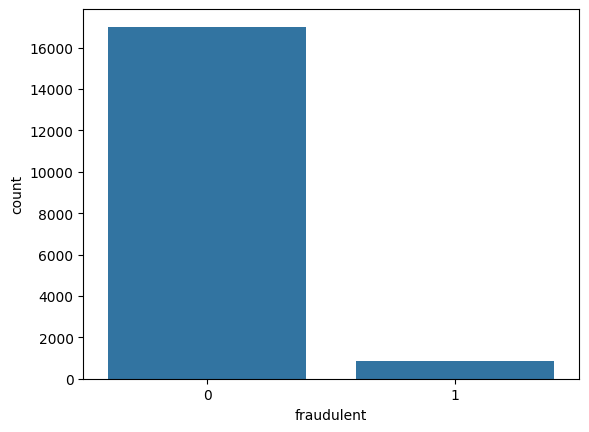

In [34]:
df['fraudulent'].value_counts()

sns.countplot(x='fraudulent', data=df)
plt.show()

In [35]:
df['text'] = (
    df['title'] + " " +
    df['company_profile'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits']
)

In [36]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [37]:
df['text'] = df['text'].apply(clean_text)

In [38]:
X = df['text']
y = df['fraudulent']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
tfidf = TfidfVectorizer(max_features=5000)

In [41]:
lr_model = Pipeline([
    ('tfidf', tfidf),
    ('classifier', LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

pred_lr = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy: 0.9541387024608501
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3395
           1       1.00      0.09      0.17       181

    accuracy                           0.95      3576
   macro avg       0.98      0.55      0.57      3576
weighted avg       0.96      0.95      0.94      3576



In [42]:
nb_model = Pipeline([
    ('tfidf', tfidf),
    ('classifier', MultinomialNB())
])

nb_model.fit(X_train, y_train)

pred_nb = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_nb))

print(classification_report(y_test, pred_nb))

Accuracy: 0.9502237136465325
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      3395
           1       0.71      0.03      0.05       181

    accuracy                           0.95      3576
   macro avg       0.83      0.51      0.51      3576
weighted avg       0.94      0.95      0.93      3576



In [43]:
dt_model = Pipeline([
    ('tfidf', tfidf),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_model.fit(X_train, y_train)

pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_dt))

print(classification_report(y_test, pred_dt))

Accuracy: 0.9552572706935123
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3395
           1       0.74      0.18      0.29       181

    accuracy                           0.96      3576
   macro avg       0.85      0.59      0.63      3576
weighted avg       0.95      0.96      0.94      3576



In [44]:
lr_acc = accuracy_score(y_test, pred_lr)
nb_acc = accuracy_score(y_test, pred_nb)
dt_acc = accuracy_score(y_test, pred_dt)

models = ['Logistic Regression', 'Naive Bayes', 'Decision Tree']
accuracy = [lr_acc, nb_acc, dt_acc]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy
})

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.954139
1          Naive Bayes  0.950224
2        Decision Tree  0.955257


In [45]:
best_model = comparison.sort_values(by='Accuracy', ascending=False)

print(best_model)

                 Model  Accuracy
2        Decision Tree  0.955257
0  Logistic Regression  0.954139
1          Naive Bayes  0.950224


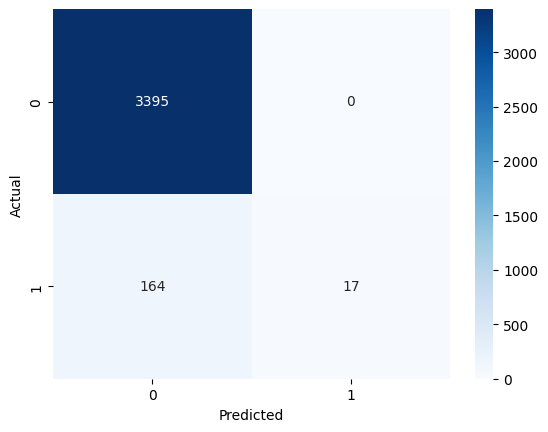

In [46]:
cm = confusion_matrix(y_test, pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [47]:
sample = """
Urgently hiring software engineers.
Excellent salary.
Work from home.
Medical insurance.
"""

prediction = lr_model.predict([sample])

if prediction[0] == 1:
    print("Fraudulent Job Posting")
else:
    print("Legitimate Job Posting")

Legitimate Job Posting


In [48]:
sample = """
Urgently hiring software engineers.
Excellent salary.
Work from home.
Medical insurance.
"""

prediction = lr_model.predict([sample])

if prediction[0] == 1:
    print("Fraudulent Job Posting")
else:
    print("Legitimate Job Posting")

Legitimate Job Posting


In [49]:
sample = """
Earn $5000 per day from home.
No experience required.
Send your bank details immediately.
Limited offer.
"""

prediction = lr_model.predict([sample])

if prediction[0] == 1:
    print("Fraudulent Job Posting")
else:
    print("Legitimate Job Posting")

Legitimate Job Posting
